# 03 — Beyond ΛCDM: decaying dark matter and parameterised gravity

Two families in `emulators/extended/` go beyond the CAMB-based suite and have their own input conventions:

* **One-body decaying dark matter (1bDDM)**, `extended/1bddm/`, trained on CLASS. A fraction `f_dcdm` of the
  dark matter decays into dark radiation with rate $\Gamma_{\rm dcdm}$; the sampled decay parameter is the product
  `Gamma_times_f` $= \Gamma_{\rm dcdm} f_{\rm dcdm}$ in Gyr⁻¹. Three degenerate massive neutrinos share the mass sum
  `m_ncdm` $= \Sigma m_\nu$ (a free input, 0 to 1 eV); $z \le 3$. Besides $P_{\rm lin}$ and $P_{\rm cb}$ it emulates background quantities, because the decay changes the
  expansion history.
* **Parameterised modified gravity**, `extended/parametrised_mg/`: boosts $B = P_{\rm MG}/P_{\Lambda{\rm CDM}}$ for a
  phenomenological $\mu(z)$, $\eta(z)$ binned in five redshift bins, linear (modified CLASS) and nonlinear (COLA
  simulations). **The MG boost grids are in $h$/Mpc**, unlike the rest of the suite.

Sections A1 to A4 cover decaying dark matter, B1 to B5 parameterised gravity.

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX

# The notebooks live in notebooks/, the emulators one level up.
EMU_DIR = next(p for p in ["../emulators", "emulators"] if os.path.isdir(p))

def load(relpath, probe="custom_log"):
    """Load one emulator file.
    probe='custom_log' : P(k) emulators, MG boosts and the DDM distances file (they store log10 of the target,
                         predict() returns the de-logged quantity)
    probe='custom'     : sigma8/fsigma8, DDM growth and DDM global emulators (values stored directly)"""
    return CosmoPowerJAX(probe=probe, filepath=os.path.join(EMU_DIR, relpath), verbose=False)

def predict(emu, **params):
    """Evaluate `emu` from keyword inputs. Scalars are broadcast against array-valued inputs,
    keys the emulator does not use are ignored. Returns an array of shape (n_samples, n_outputs)."""
    arrs = {k: np.atleast_1d(np.asarray(v, dtype=float)) for k, v in params.items()}
    missing = [p for p in emu.parameters if p not in arrs]
    if missing:
        raise KeyError(f"missing inputs {missing}; this emulator expects {list(emu.parameters)}")
    n = max(a.size for a in arrs.values())
    inputs = {p: (np.full(n, arrs[p][0]) if arrs[p].size == 1 else arrs[p]) for p in emu.parameters}
    return np.atleast_2d(np.asarray(emu.predict(inputs)))

plt.rcParams.update({"font.size": 11, "figure.dpi": 100})

# Planck-2018-like fiducial point, in the parameter names used by the CAMB-family emulators
PLANCK = dict(ombh2=0.0224, omch2=0.120, H0=67.4, ns=0.965, lnAs=3.044)
print("emulator directory:", os.path.abspath(EMU_DIR))

emulator directory: /Users/ivan/Desktop/dr1-matter-emulators/emulators


## A1. Linear suppression from decaying dark matter

Inputs of the DDM files are named in the CLASS convention: `omega_b`, `omega_cdm_tot` (the **total** cold dark
matter density today, stable + decaying), `h`, `n_s`, `ln10^{10}A_s`, `z`, `f_dcdm`, `Gamma_times_f` and `m_ncdm`
(the neutrino mass sum in eV). The decay
lowers the matter density at late times and injects free-streaming radiation: power is enhanced on the largest
scales and suppressed by a nearly constant factor at $k \gtrsim 0.1$ Mpc⁻¹, a factor that depends mostly on the
product $\Gamma f$ (right panel). The ΛCDM limit is $f_{\rm dcdm} = 0$ or $\Gamma f = 0$.

inputs: ['omega_b', 'omega_cdm_tot', 'h', 'n_s', 'ln10^{10}A_s', 'z', 'f_dcdm', 'Gamma_times_f', 'm_ncdm']


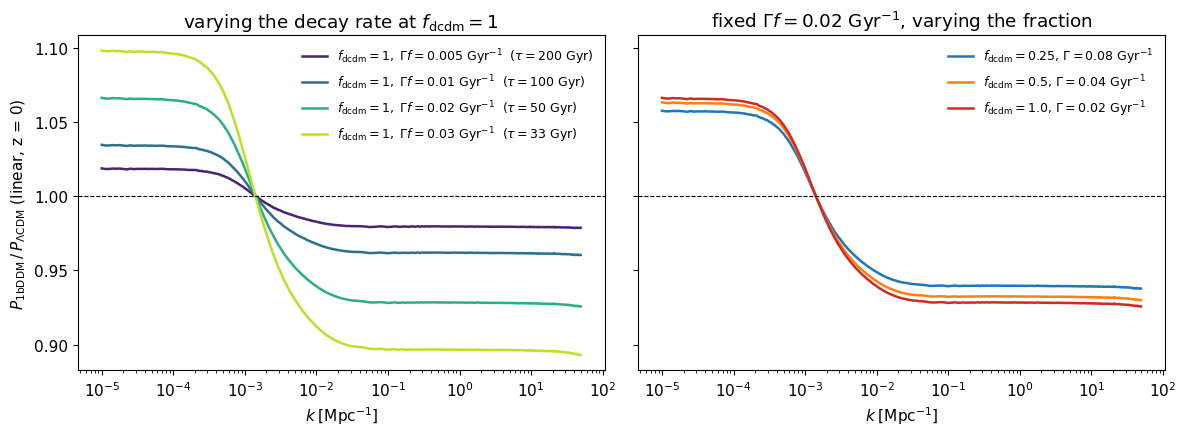

In [2]:
DDM = {"omega_b": 0.0224, "omega_cdm_tot": 0.120, "h": 0.674, "n_s": 0.965, "ln10^{10}A_s": 3.044, "m_ncdm": 0.06}

ddm_lin = load("extended/1bddm/ddm-1body-neutrino-linear.npz")
ddm_cb  = load("extended/1bddm/ddm-1body-neutrino-cb-linear.npz")
k = np.asarray(ddm_lin.modes)
print("inputs:", list(ddm_lin.parameters))

p_lcdm = predict(ddm_lin, **DDM, f_dcdm=0.0, Gamma_times_f=0.0, z=0.0)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for gf, c in zip([0.005, 0.01, 0.02, 0.03], plt.cm.viridis(np.linspace(0.1, 0.9, 4))):
    p = predict(ddm_lin, **DDM, f_dcdm=1.0, Gamma_times_f=gf, z=0.0)[0]
    axes[0].semilogx(k, p / p_lcdm, color=c, lw=1.8, label=rf"$f_{{\rm dcdm}}=1,\ \Gamma f={gf}$ Gyr$^{{-1}}$  ($\tau={1/gf:.0f}$ Gyr)")
for f, c in zip([0.25, 0.5, 1.0], ["C0", "C1", "C3"]):
    p = predict(ddm_lin, **DDM, f_dcdm=f, Gamma_times_f=0.02, z=0.0)[0]
    axes[1].semilogx(k, p / p_lcdm, color=c, lw=1.8, label=rf"$f_{{\rm dcdm}}={f}$, $\Gamma={0.02/f:.2f}$ Gyr$^{{-1}}$")
for ax, title in zip(axes, ["varying the decay rate at $f_{\\rm dcdm} = 1$", r"fixed $\Gamma f = 0.02$ Gyr$^{-1}$, varying the fraction"]):
    ax.axhline(1, color="k", lw=0.8, ls="--"); ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", title=title); ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel(r"$P_{\rm 1bDDM}\,/\,P_{\Lambda{\rm CDM}}$ (linear, z = 0)")
plt.tight_layout(); plt.show()

## A2. The ΛCDM limit against the CAMB-based suite

At $f_{\rm dcdm} = 0$ the DDM emulator should reproduce ΛCDM with three degenerate neutrinos of mass sum
`m_ncdm`, which is exactly `lcdm-3mass-linear.npz` at `mnu = m_ncdm`. The two emulators were trained on different
Boltzmann codes (CLASS and CAMB), so the residual below is the code-to-code difference plus the two emulator errors;
it stays at the few-per-mille level for every mass. The mapping between the input conventions is
$\omega_b = $ `omega_b`, $\omega_c = $ `omega_cdm_tot`, $H_0 = 100\,h$, `mnu` $=$ `m_ncdm`.

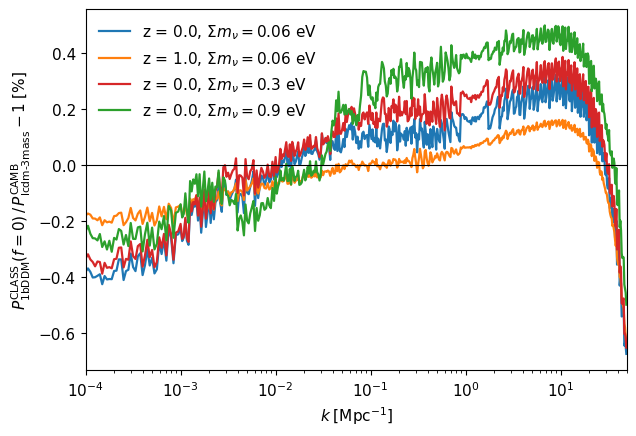

In [3]:
lcdm3 = load("lcdm/hmcode/lcdm-3mass-linear.npz")
camb_point = dict(ombh2=DDM["omega_b"], omch2=DDM["omega_cdm_tot"], H0=100 * DDM["h"], ns=DDM["n_s"], lnAs=DDM["ln10^{10}A_s"], mnu=DDM["m_ncdm"])

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for (z, mnu), c in zip([(0.0, 0.06), (1.0, 0.06), (0.0, 0.3), (0.0, 0.9)], ["C0", "C1", "C3", "C2"]):
    p_ddm  = predict(ddm_lin, **{**DDM, "m_ncdm": mnu}, f_dcdm=0.0, Gamma_times_f=0.0, z=z)[0]
    p_camb = predict(lcdm3, **{**camb_point, "mnu": mnu}, z=z)[0]
    ax.semilogx(k, 100 * (p_ddm / p_camb - 1), color=c, lw=1.6, label=rf"z = {z}, $\Sigma m_\nu = {mnu}$ eV")
ax.axhline(0, color="k", lw=0.8); ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P^{\rm CLASS}_{\rm 1bDDM}(f=0)\,/\,P^{\rm CAMB}_{\rm lcdm\text{-}3mass} - 1\;[\%]$", xlim=(1e-4, 50))
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## A3. Background and growth emulators

Because the decay changes $H(z)$, the DDM family also emulates background quantities. Three scalar files:

| File | `probe` | Outputs |
|---|---|---|
| `ddm-1body-neutrino-distances` | `custom_log` | $H(z)$ in Mpc⁻¹ (multiply by $c = 299\,792.458$ km/s for km/s/Mpc), $D_A(z)$ and $D_L(z)$ in Mpc; valid for $z \ge 0.02$ |
| `ddm-1body-neutrino-growth` | `custom` | $\sigma_8(z)$, $f\sigma_8(z)$ |
| `ddm-1body-neutrino-global` | `custom` | $\sigma_8(z{=}0)$, $\Omega_m$, $r_{\rm drag}$ in Mpc; no `z` input |

As a check, the $f_{\rm dcdm} = 0$ Hubble rate is compared with the analytic flat-ΛCDM expression for the same densities
(neutrinos counted as matter, photons as radiation).

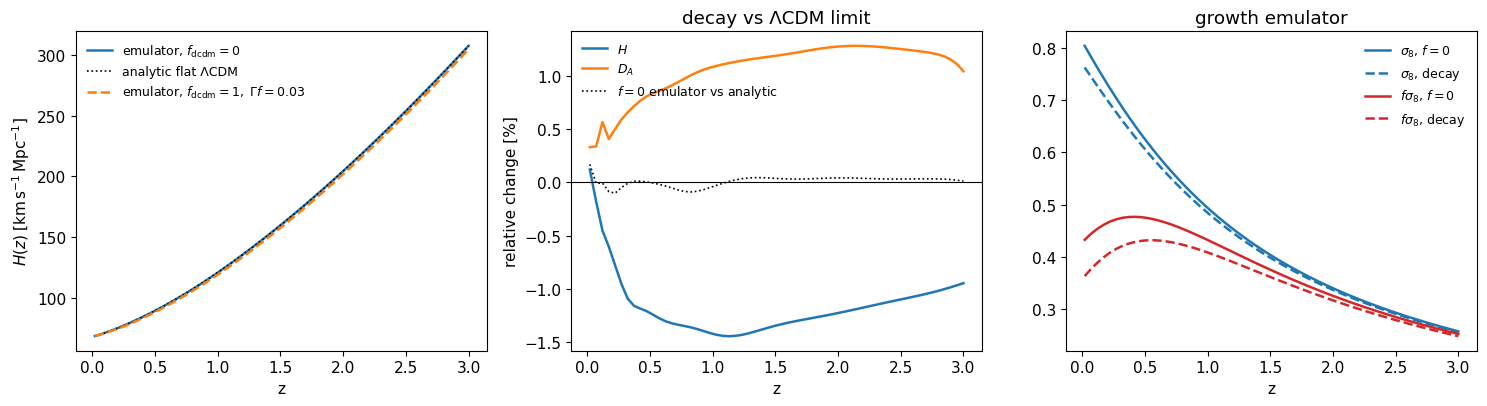

global emulator  [sigma8(0), Omega_m, r_drag/Mpc]
  LCDM limit           sigma8 = 0.8127   Omega_m = 0.3172   r_drag = 147.09 Mpc
  f=1, Gamma f=0.03    sigma8 = 0.7705   Omega_m = 0.2250   r_drag = 147.11 Mpc


In [4]:
ddm_dis = load("extended/1bddm/ddm-1body-neutrino-distances.npz")                 # stores log10 -> custom_log
ddm_gro = load("extended/1bddm/ddm-1body-neutrino-growth.npz", probe="custom")
ddm_glo = load("extended/1bddm/ddm-1body-neutrino-global.npz", probe="custom")
c_kms = 299792.458

z = np.linspace(0.02, 3.0, 60)
lcdm_lim = dict(f_dcdm=0.0, Gamma_times_f=0.0)
decay    = dict(f_dcdm=1.0, Gamma_times_f=0.03)

H0_, DA0, DL0 = predict(ddm_dis, **DDM, **lcdm_lim, z=z).T
H1_, DA1, DL1 = predict(ddm_dis, **DDM, **decay, z=z).T
s8_0, fs8_0 = predict(ddm_gro, **DDM, **lcdm_lim, z=z).T
s8_1, fs8_1 = predict(ddm_gro, **DDM, **decay, z=z).T

# analytic flat LCDM for the f = 0 point
h = DDM["h"]; om = (DDM["omega_b"] + DDM["omega_cdm_tot"] + DDM["m_ncdm"] / 93.14) / h**2; og = 2.47e-5 / h**2
H_an = 100 * h * np.sqrt(om * (1 + z) ** 3 + og * (1 + z) ** 4 + (1 - om - og))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(z, H0_ * c_kms, lw=1.8, label=r"emulator, $f_{\rm dcdm}=0$"); axes[0].plot(z, H_an, "k:", lw=1.2, label="analytic flat ΛCDM")
axes[0].plot(z, H1_ * c_kms, lw=1.8, ls="--", label=r"emulator, $f_{\rm dcdm}=1,\ \Gamma f=0.03$")
axes[0].set(xlabel="z", ylabel=r"$H(z)\;[\mathrm{km\,s^{-1}\,Mpc^{-1}}]$"); axes[0].legend(frameon=False, fontsize=9)
axes[1].plot(z, 100 * (H1_ / H0_ - 1), lw=1.8, label=r"$H$"); axes[1].plot(z, 100 * (DA1 / DA0 - 1), lw=1.8, label=r"$D_A$")
axes[1].plot(z, 100 * (H0_ * c_kms / H_an - 1), "k:", lw=1.2, label=r"$f=0$ emulator vs analytic")
axes[1].axhline(0, color="k", lw=0.8); axes[1].set(xlabel="z", ylabel="relative change [%]", title="decay vs ΛCDM limit"); axes[1].legend(frameon=False, fontsize=9)
axes[2].plot(z, s8_0, "C0", lw=1.8, label=r"$\sigma_8$, $f=0$"); axes[2].plot(z, s8_1, "C0--", lw=1.8, label=r"$\sigma_8$, decay")
axes[2].plot(z, fs8_0, "C3", lw=1.8, label=r"$f\sigma_8$, $f=0$"); axes[2].plot(z, fs8_1, "C3--", lw=1.8, label=r"$f\sigma_8$, decay")
axes[2].set(xlabel="z", title="growth emulator"); axes[2].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

print("global emulator  [sigma8(0), Omega_m, r_drag/Mpc]")
for lab, pars in [("LCDM limit", lcdm_lim), ("f=1, Gamma f=0.03", decay)]:
    s8, Om, rd = predict(ddm_glo, **DDM, **pars)[0]
    print(f"  {lab:20s} sigma8 = {s8:.4f}   Omega_m = {Om:.4f}   r_drag = {rd:.2f} Mpc")

## A4. Reconstructing the nonlinear 1bDDM spectrum

Halo-model prescriptions are not calibrated for a decaying component, so the nonlinear DDM spectrum is not
emulated. Following the paper (and Lesgourgues et al. 2024) it is reconstructed from the ΛCDM nonlinear
emulator and a decay-induced boost built from the linear emulators and the $N$-body-calibrated fitting formula
of Hubert et al. (2021):

$$P^{\rm 1bDDM}_{\rm nl}(k,z) = S(k,z)\,P^{\Lambda{\rm CDM}}_{\rm nl}(k,z),\qquad
S = \frac{P^{\rm 1bDDM}_{\rm lin}}{P^{\Lambda{\rm CDM}}_{\rm lin}}\;\frac{1-\varepsilon_{\rm nl}(k,z)}{1-\varepsilon_{\rm lin}(z)} .$$

The functions below are the Hubert et al. fits as implemented in `cloelib` ($\Gamma$ in Gyr⁻¹, $k$ passed in
Mpc⁻¹, $\omega_m = \omega_b + \omega_{\rm cdm}^{\rm tot}$). The ΛCDM baseline is `lcdm-3mass-nonlinear` at the
same neutrino mass sum (`mnu = m_ncdm`); either HMCode2020 or Halofit can be used. The formula was
calibrated for lifetimes $\gtrsim 30$ Gyr, $z \lesssim 2.3$ and $k \lesssim$ a few Mpc⁻¹.

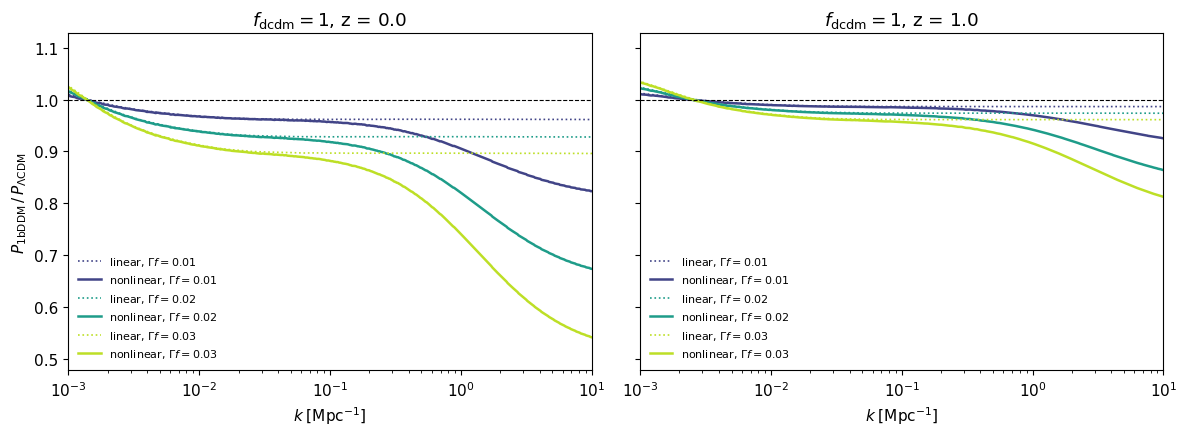

In [5]:
def eps_lin(z, wb, h, wm, f, Gamma):
    """Hubert et al. (2021) linear suppression epsilon_lin(z); Gamma in 1/Gyr."""
    u, v, w = wb / 0.02216, h / 0.6776, wm / 0.1412
    eps1 = 5.323 - 1.4644 * u - 1.391 * v + (-2.055 + 1.329 * u + 0.8672 * v) * w + (0.2682 - 0.3509 * u) * w * w
    eps2 = 0.9260 + (0.05735 - 0.02690 * v) * w + (-0.01373 + 0.006713 * v) * w * w
    eps3 = (9.553 - 0.7860 * v) + (0.4884 + 0.1754 * v) * w + (-0.2512 + 0.07558 * v) * w * w
    return f * eps1 * Gamma ** eps2 * (1.0 / (1.0 + 0.105 * z)) ** eps3

def eps_nonlin(z, k, wb, h, wm, f, Gamma):
    """Hubert et al. (2021) nonlinear suppression epsilon_nl(k, z); returns shape (len(z), len(k))."""
    z = np.atleast_1d(z)[:, None]; k = np.atleast_1d(k)[None, :]
    s = 1.0 / (1.0 + 1.1 * z)
    a = 0.7208 + 2.027 * Gamma + (3.431 - 0.4) * s - 0.18
    b = 0.0120 + 2.786 * Gamma + (0.6499 + 0.02) * s - 0.09
    p = 1.045 + 1.225 * Gamma + 0.2207 * s - 0.099
    q = 0.9922 + 1.735 * Gamma + 0.2154 * s - 0.056
    return eps_lin(z, wb, h, wm, f, Gamma) * (1.0 + a * k ** p) / (1.0 + b * k ** q)

def ddm_nonlinear(z, f_dcdm, Gamma_times_f, logT_AGN=7.8):
    """P_nl^1bDDM(k, z) on the emulator k-grid, reconstructed from the LCDM 3mass HMCode2020 emulator."""
    z = np.atleast_1d(np.asarray(z, float))
    p_nl_lcdm  = predict(lcdm3_nl, **camb_point, logT_AGN=logT_AGN, z=z)
    p_lin_lcdm = predict(lcdm3, **camb_point, z=z)
    p_lin_ddm  = predict(ddm_lin, **DDM, f_dcdm=f_dcdm, Gamma_times_f=Gamma_times_f, z=z)
    if f_dcdm == 0.0 or Gamma_times_f == 0.0:
        return p_nl_lcdm
    Gamma = Gamma_times_f / f_dcdm
    wb, h, wm = DDM["omega_b"], DDM["h"], DDM["omega_b"] + DDM["omega_cdm_tot"]
    S = (p_lin_ddm / p_lin_lcdm) * (1.0 - eps_nonlin(z, k, wb, h, wm, f_dcdm, Gamma)) / (1.0 - eps_lin(z, wb, h, wm, f_dcdm, Gamma))[:, None]
    return S * p_nl_lcdm

lcdm3_nl = load("lcdm/hmcode/lcdm-3mass-nonlinear.npz")
zs = np.array([0.0, 1.0])
p_nl_ref = ddm_nonlinear(zs, 0.0, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (iz, z) in zip(axes, enumerate(zs)):
    for gf, c in zip([0.01, 0.02, 0.03], plt.cm.viridis(np.linspace(0.2, 0.9, 3))):
        p_lin = predict(ddm_lin, **DDM, f_dcdm=1.0, Gamma_times_f=gf, z=z)[0] / predict(ddm_lin, **DDM, f_dcdm=0.0, Gamma_times_f=0.0, z=z)[0]
        p_nl  = ddm_nonlinear(z, 1.0, gf)[0] / p_nl_ref[iz]
        ax.semilogx(k, p_lin, color=c, lw=1.2, ls=":", label=rf"linear, $\Gamma f={gf}$")
        ax.semilogx(k, p_nl,  color=c, lw=1.8, label=rf"nonlinear, $\Gamma f={gf}$")
    ax.axhline(1, color="k", lw=0.8, ls="--"); ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", title=rf"$f_{{\rm dcdm}}=1$, z = {z}", xlim=(1e-3, 10))
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel(r"$P_{\rm 1bDDM}\,/\,P_{\Lambda{\rm CDM}}$")
plt.tight_layout(); plt.show()

## B1. Parameterised gravity: the boost emulators and their conventions

Departures from GR are parameterised by $\mu$ (strength of gravity in the Poisson equation) and $\eta$
(gravitational slip), piecewise constant in five redshift bins:

| file index | bin | redshift range |
|---|---|---|
| `bin0` | 1 | 0 ≤ z < 0.43 |
| `bin1` | 2 | 0.43 ≤ z < 0.91 |
| `bin2` | 3 | 0.91 ≤ z < 1.47 |
| `bin3` | 4 | 1.47 ≤ z < 2.15 |
| `bin4` | 5 | 2.15 ≤ z < 3.0 |

Two variants: **single-bin** files (`mg-boost-{linear,nonlinear}-bin{0..4}`) modify one bin with the others at GR
and take scalar `mu`, `eta`; **multi-bin** files take `mu1..mu5` and `eta1..eta5` jointly. $\eta$ affects only
photons, so it enters the linear boost only; the nonlinear (COLA) boosts take `mu` alone. Cosmology inputs are
`Omega_m`, `Omega_b`, `h`, `ns`, `lnAs` (not $\omega_b$, $\omega_c$, $H_0$). Conventions to respect, as in the `cloelib`
implementation used for the paper:

* the boost grids `modes` are in **$h$/Mpc**;
* a single-bin emulator is trained only up to the top edge of its own bin and extrapolates badly above it.
  Evaluate it for $z \le z_{\rm top}$ and set $B = 1$ above (for the multi-bin files $z_{\rm top} = 3$);
* training boxes differ between the variants (single-bin: $\Omega_m \in [0.25, 0.35]$, $h \in [0.65, 0.73]$,
  $n_s \in [0.95, 1.00]$, $\ln 10^{10}A_s \in [2.996, 3.091]$, $z \in [0.01, 3]$; multi-bin: $\Omega_m \in [0.25, 0.40]$,
  $h \in [0.65, 0.75]$, $n_s \in [0.80, 1.20]$, $\ln 10^{10}A_s \in [2.944, 3.219]$, $z \in [0, 3]$; both
  $\Omega_b \in [0.040, 0.055]$ and $\mu, \eta \in [0.9, 1.1]$).

First the GR limit: at $\mu = \eta = 1$ every boost must be one.

In [6]:
MG = dict(Omega_m=0.31, Omega_b=0.049, h=0.674, ns=0.965, lnAs=3.044)
BIN_EDGES = [(0.00, 0.43), (0.43, 0.91), (0.91, 1.47), (1.47, 2.15), (2.15, 3.00)]

mg_lin = [load(f"extended/parametrised_mg/mg-boost-linear-bin{i}.npz") for i in range(5)]
mg_nl  = [load(f"extended/parametrised_mg/mg-boost-nonlinear-bin{i}.npz") for i in range(5)]
mg_lin_multi = load("extended/parametrised_mg/mg-boost-linear-multibin.npz")
mg_nl_multi  = load("extended/parametrised_mg/mg-boost-nonlinear-multibin.npz")
kh_lin, kh_nl = np.asarray(mg_lin[0].modes), np.asarray(mg_nl[0].modes)        # h/Mpc
print("linear single-bin inputs :", list(mg_lin[0].parameters), f"| {len(kh_lin)} modes, k = {kh_lin[0]:.0e}..{kh_lin[-1]:.0f} h/Mpc")
print("nonlinear single-bin     :", list(mg_nl[0].parameters),  f"| {len(kh_nl)} modes, k = {kh_nl[0]:.3f}..{kh_nl[-1]:.1f} h/Mpc")
print("linear multi-bin inputs  :", list(mg_lin_multi.parameters))

def mg_boost(emu, z, bin_index=None, **params):
    """Boost B(k, z), shape (len(z), n_modes). Queries the network only for z <= z_top
    (top edge of the active bin for single-bin files, 3.0 for multi-bin) and sets B = 1 above."""
    z = np.atleast_1d(np.asarray(z, float))
    z_top = 3.0 if bin_index is None else BIN_EDGES[bin_index][1]
    B = np.ones((z.size, len(emu.modes)))
    active = z <= z_top
    if active.any():
        B[active] = predict(emu, **params, z=z[active])
    return B

print("\nGR limit, max |B - 1| at the bin centre:")
for i, (zlo, zhi) in enumerate(BIN_EDGES):
    zc = 0.5 * (zlo + zhi)
    b_lin = mg_boost(mg_lin[i], zc, i, **MG, mu=1.0, eta=1.0)
    b_nl  = mg_boost(mg_nl[i],  zc, i, **MG, mu=1.0)
    print(f"  bin{i} (z = {zc:.2f}):  linear {np.abs(b_lin - 1).max():.4f}   nonlinear {np.abs(b_nl - 1).max():.4f}")
gr5 = {f"mu{i}": 1.0 for i in range(1, 6)} | {f"eta{i}": 1.0 for i in range(1, 6)}
print(f"  multi-bin (z = 0.5): linear {np.abs(mg_boost(mg_lin_multi, 0.5, None, **MG, **gr5) - 1).max():.4f}   "
      f"nonlinear {np.abs(mg_boost(mg_nl_multi, 0.5, None, **MG, **{k_: v for k_, v in gr5.items() if k_.startswith('mu')}) - 1).max():.4f}")

linear single-bin inputs : ['Omega_m', 'Omega_b', 'h', 'ns', 'lnAs', 'mu', 'eta', 'z'] | 800 modes, k = 1e-04..10 h/Mpc
nonlinear single-bin     : ['Omega_m', 'Omega_b', 'h', 'ns', 'lnAs', 'mu', 'z'] | 1024 modes, k = 0.016..12.6 h/Mpc
linear multi-bin inputs  : ['Omega_m', 'Omega_b', 'h', 'ns', 'lnAs', 'mu1', 'mu2', 'mu3', 'mu4', 'mu5', 'eta1', 'eta2', 'eta3', 'eta4', 'eta5', 'z']

GR limit, max |B - 1| at the bin centre:
  bin0 (z = 0.21):  linear 0.0000   nonlinear 0.0004
  bin1 (z = 0.67):  linear 0.0000   nonlinear 0.0017
  bin2 (z = 1.19):  linear 0.0000   nonlinear 0.0001
  bin3 (z = 1.81):  linear 0.0000   nonlinear 0.0012
  bin4 (z = 2.58):  linear 0.0000   nonlinear 0.0019


  multi-bin (z = 0.5): linear 0.0000   nonlinear 0.0003


## B2. The linear boost: $\mu$ and $\eta$ in the lowest bin

With the lowest-redshift bin active, $\mu > 1$ strengthens gravity and enhances clustering; $\eta$ has a much
smaller effect on the matter spectrum. Both are shown at $z = 0.2$, inside the bin.

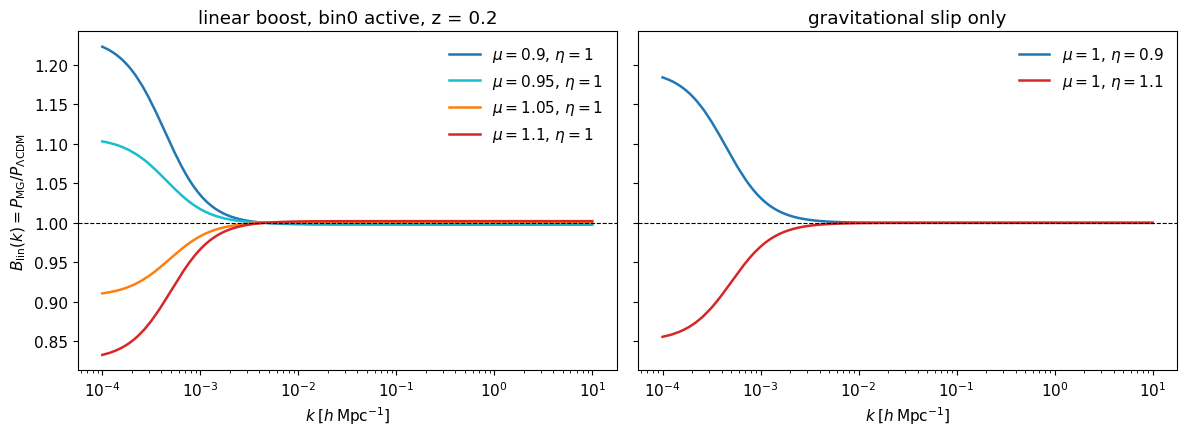

In [7]:
z0 = 0.2
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for mu, c in zip([0.9, 0.95, 1.05, 1.1], ["C0", "C9", "C1", "C3"]):
    axes[0].semilogx(kh_lin, mg_boost(mg_lin[0], z0, 0, **MG, mu=mu, eta=1.0)[0], color=c, lw=1.8, label=rf"$\mu={mu}$, $\eta=1$")
for eta, c in zip([0.9, 1.1], ["C0", "C3"]):
    axes[1].semilogx(kh_lin, mg_boost(mg_lin[0], z0, 0, **MG, mu=1.0, eta=eta)[0], color=c, lw=1.8, label=rf"$\mu=1$, $\eta={eta}$")
for ax in axes:
    ax.axhline(1, color="k", lw=0.8, ls="--"); ax.set(xlabel=r"$k\;[h\,\mathrm{Mpc}^{-1}]$"); ax.legend(frameon=False)
axes[0].set(ylabel=r"$B_{\rm lin}(k) = P_{\rm MG}/P_{\Lambda{\rm CDM}}$", title=f"linear boost, bin0 active, z = {z0}")
axes[1].set(title="gravitational slip only")
plt.tight_layout(); plt.show()

## B3. Redshift dependence and the $z_{\rm top}$ rule

A modification confined to one bin changes the growth while that bin is active; at lower redshift the imprint
remains, at higher redshift the Universe is GR and $B = 1$. The `mg_boost` helper enforces this: the network is
queried only up to the top edge of the active bin. Here $B$ at $k = 0.1\,h$/Mpc is followed across $z \in [0.01, 3]$
for each single-bin emulator with $\mu = 1.1$.

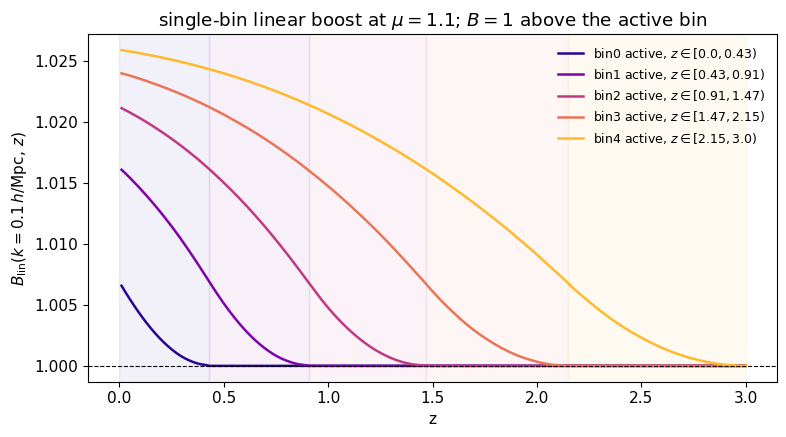

In [8]:
zz = np.linspace(0.01, 3.0, 150)
ik = np.argmin(np.abs(kh_lin - 0.1))
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, c in enumerate(plt.cm.plasma(np.linspace(0.05, 0.85, 5))):
    B = mg_boost(mg_lin[i], zz, i, **MG, mu=1.1, eta=1.0)[:, ik]
    ax.plot(zz, B, color=c, lw=1.8, label=f"bin{i} active, $z \\in [{BIN_EDGES[i][0]}, {BIN_EDGES[i][1]})$")
    ax.axvspan(*BIN_EDGES[i], color=c, alpha=0.06)
ax.axhline(1, color="k", lw=0.8, ls="--")
ax.set(xlabel="z", ylabel=r"$B_{\rm lin}(k=0.1\,h/{\rm Mpc},\,z)$", title=r"single-bin linear boost at $\mu = 1.1$; $B = 1$ above the active bin")
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

## B4. Nonlinear boost, and single-bin versus multi-bin

The nonlinear boosts come from pairs of COLA simulations (modified gravity and ΛCDM with identical initial
conditions) and cover $k \simeq 0.016$ to $12.6\,h$/Mpc. Compared with the linear boost at the same $\mu$ the
nonlinear response is damped on small scales. The multi-bin emulator with only $\mu_1 \neq 1$ should agree with
the single-bin `bin0` file; the two were trained on different simulation suites and boxes, so the residual is a
measure of their accuracy.

grids: single-bin linear 800 modes, multi-bin linear 512 modes; nonlinear 1024 / 1024 modes


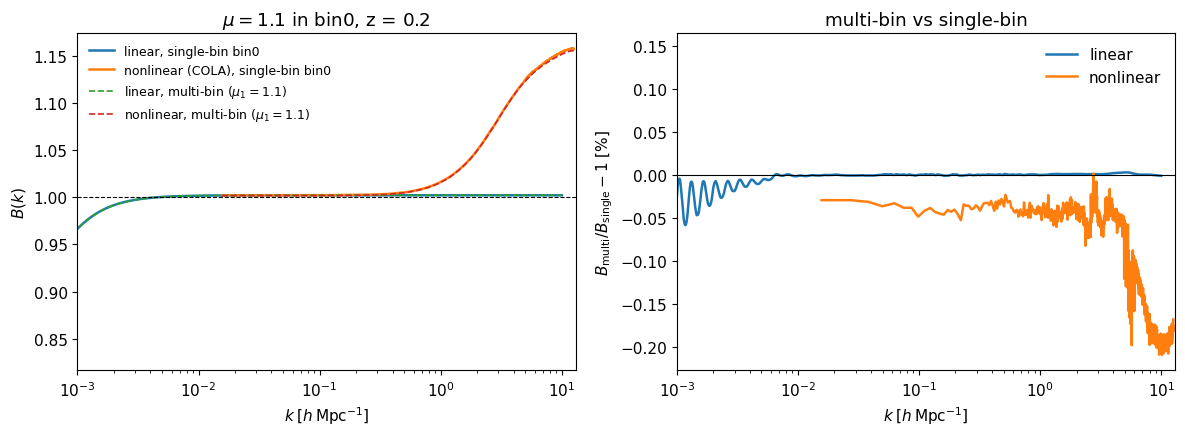

In [9]:
z0 = 0.2
mu5 = {f"mu{i}": 1.0 for i in range(1, 6)} | {"mu1": 1.1}
eta5 = {f"eta{i}": 1.0 for i in range(1, 6)}

b_lin_single = mg_boost(mg_lin[0], z0, 0, **MG, mu=1.1, eta=1.0)[0]
b_nl_single  = mg_boost(mg_nl[0],  z0, 0, **MG, mu=1.1)[0]
b_lin_multi  = mg_boost(mg_lin_multi, z0, None, **MG, **mu5, **eta5)[0]
b_nl_multi   = mg_boost(mg_nl_multi,  z0, None, **MG, **mu5)[0]
kh_lin_m, kh_nl_m = np.asarray(mg_lin_multi.modes), np.asarray(mg_nl_multi.modes)   # the multi-bin files have their own grids
print(f"grids: single-bin linear {len(kh_lin)} modes, multi-bin linear {len(kh_lin_m)} modes; nonlinear {len(kh_nl)} / {len(kh_nl_m)} modes")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].semilogx(kh_lin, b_lin_single, lw=1.8, label="linear, single-bin bin0")
axes[0].semilogx(kh_nl,  b_nl_single,  lw=1.8, label="nonlinear (COLA), single-bin bin0")
axes[0].semilogx(kh_lin_m, b_lin_multi, lw=1.2, ls="--", label=r"linear, multi-bin ($\mu_1=1.1$)")
axes[0].semilogx(kh_nl_m,  b_nl_multi,  lw=1.2, ls="--", label=r"nonlinear, multi-bin ($\mu_1=1.1$)")
axes[0].axhline(1, color="k", lw=0.8, ls="--"); axes[0].set(xlabel=r"$k\;[h\,\mathrm{Mpc}^{-1}]$", ylabel=r"$B(k)$", title=rf"$\mu = 1.1$ in bin0, z = {z0}", xlim=(1e-3, 13))
axes[0].legend(frameon=False, fontsize=9)
# ratios on the single-bin grids (interpolating the multi-bin boosts in log k)
r_lin = np.interp(np.log(kh_lin), np.log(kh_lin_m), b_lin_multi) / b_lin_single
r_nl  = np.interp(np.log(kh_nl),  np.log(kh_nl_m),  b_nl_multi)  / b_nl_single
axes[1].semilogx(kh_lin, 100 * (r_lin - 1), lw=1.8, label="linear")
axes[1].semilogx(kh_nl,  100 * (r_nl - 1),  lw=1.8, label="nonlinear")
axes[1].axhline(0, color="k", lw=0.8); axes[1].set(xlabel=r"$k\;[h\,\mathrm{Mpc}^{-1}]$", ylabel=r"$B_{\rm multi}/B_{\rm single} - 1\;[\%]$", title="multi-bin vs single-bin", xlim=(1e-3, 13))
axes[1].legend(frameon=False); plt.tight_layout(); plt.show()

## B5. Applying the boost to a ΛCDM spectrum

The boost multiplies a ΛCDM spectrum from the main suite: $P_{\rm MG}(k,z) = B(k,z)\,P_{\Lambda{\rm CDM}}(k,z)$.
Two conversions are needed: the MG cosmology $(\Omega_m, \Omega_b, h)$ maps to $\omega_b = \Omega_b h^2$,
$\omega_c = (\Omega_m - \Omega_b)h^2$, $H_0 = 100h$ for the ΛCDM emulator, and the boost grid in $h$/Mpc maps to
the ΛCDM grid in Mpc⁻¹ through $k_{\rm Mpc^{-1}} = h\,k_{h/{\rm Mpc}}$. Outside the boost grid the boost is held
constant at its edge values (as `cloelib` does). The choice of ΛCDM baseline (neutrino variant, nonlinear
prescription, feedback) is the user's; here `lcdm-1mass-nonlinear` with $\Sigma m_\nu = 0.06$ eV.

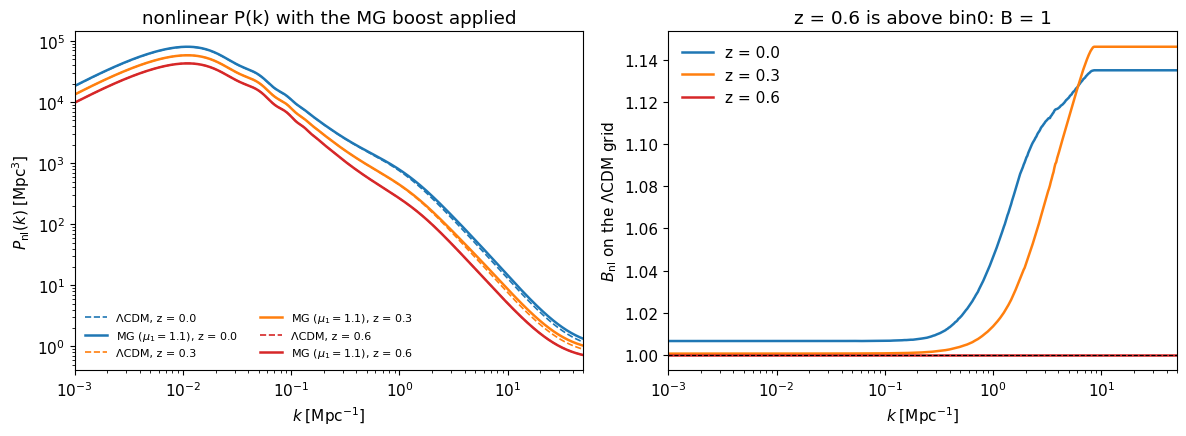

In [10]:
lcdm_nl = load("lcdm/hmcode/lcdm-1mass-nonlinear.npz")
k_mpc = np.asarray(lcdm_nl.modes)
h = MG["h"]
lcdm_point = dict(ombh2=MG["Omega_b"] * h**2, omch2=(MG["Omega_m"] - MG["Omega_b"]) * h**2, H0=100 * h, ns=MG["ns"], lnAs=MG["lnAs"], mnu=0.06, logT_AGN=7.8)

def boost_on_mpc_grid(emu, z, bin_index, k_mpc, **params):
    """Interpolate a boost (grid in h/Mpc) onto a k grid in Mpc^-1, constant beyond the boost grid edges."""
    B = mg_boost(emu, z, bin_index, **params)
    kh = np.asarray(emu.modes)
    return np.array([np.interp(np.log(k_mpc / h), np.log(kh), row) for row in B])   # np.interp clamps at the edges

zs = np.array([0.0, 0.3, 0.6])
p_lcdm = predict(lcdm_nl, **lcdm_point, z=zs)
B = boost_on_mpc_grid(mg_nl[0], zs, 0, k_mpc, **MG, mu=1.1)
p_mg = B * p_lcdm

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for i, (z, c) in enumerate(zip(zs, ["C0", "C1", "C3"])):
    axes[0].loglog(k_mpc, p_lcdm[i], color=c, lw=1.2, ls="--", label=f"ΛCDM, z = {z}")
    axes[0].loglog(k_mpc, p_mg[i],   color=c, lw=1.8, label=rf"MG ($\mu_1=1.1$), z = {z}")
    axes[1].semilogx(k_mpc, B[i], color=c, lw=1.8, label=f"z = {z}")
axes[0].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm nl}(k)\;[\mathrm{Mpc}^3]$", xlim=(1e-3, 50), title="nonlinear P(k) with the MG boost applied")
axes[0].legend(frameon=False, fontsize=8, ncol=2)
axes[1].axhline(1, color="k", lw=0.8, ls="--"); axes[1].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$B_{\rm nl}$ on the ΛCDM grid", xlim=(1e-3, 50), title="z = 0.6 is above bin0: B = 1")
axes[1].legend(frameon=False); plt.tight_layout(); plt.show()

## Summary

* **1bDDM**: CLASS conventions for the inputs, $z \le 3$, free neutrino mass sum `m_ncdm`. Linear $P$ and $P_{\rm cb}$ are emulated;
  the background comes from the `distances` (log-stored, `custom_log`) and `global` files; the nonlinear spectrum is
  rebuilt from the ΛCDM `3mass` emulators with the Hubert et al. boost.
* **Parameterised MG**: boosts on an $h$/Mpc grid, `Omega_m`-style cosmology inputs, $\eta$ in the linear boost only,
  and a hard $z_{\rm top}$ rule for the single-bin files. Multiply onto any ΛCDM baseline after converting the grid.
* The halo-model-reaction emulators (f(R), nDGP, Dark Scattering, $\mu(k,z)$) are not in this repository; see
  `emulators/extended/react/README.md`.